# Automotive Valuation & Market Strategy Analysis

Author & Data Scientist: Jonathan Felix Yashim  
GitHub: [@JFYashim](https://github.com/JFYashim)  
Role: Lead Data Analyst / Data Scientist  

---

## Executive Summary
This project analyzes sales data across 5,500 used vehicles to help auto dealerships set better listing prices, make smarter trade-in offers, and move inventory faster.

* Market Scale & Coverage: Evaluated 5,500 vehicle records across 18 specifications, cleaning missing entries across engine and history metrics to ensure 100% data completeness.
* Inventory Depletion Tracking: Vehicle age is the primary driver of price drops over time, though recent models with low mileage continue to command top dollar.
* Feature Engineering: Created new tracking variables for vehicle age and mapped high-demand features (make, model, location, and color) to improve model prediction accuracy.

---

## Business Context
A nationwide used-car dealership network is upgrading how it prices inventory and allocates its buying budget. In the past, sales managers depended on personal experience and local gut feel to evaluate trade-ins and set sticker prices. With modern online car sites making prices fully visible to consumers, the business needs a data-driven model to protect profit margins and sell vehicles faster.

---

## Core Problem Statement
How can the business optimize unit pricing, trade-in valuations, and regional inventory distribution to maximize gross profit margins while minimizing days-on-market for pre-owned vehicles?

---

## Key Business & Research Questions
* **The Power Premium:** Do larger engines (`Engine_Size`) and higher horsepower (`Horsepower`) command higher selling prices across different body styles?
* **Depreciation & Mileage:** How strongly do `Vehicle_Age` and total `Mileage` combine to drive down vehicle resale value?
* **Accident Penalty:** What is the precise financial impact of a recorded accident (`Accident_History`) on final listing prices?
* **Regional Preferences:** Does vehicle demand vary by location (`Location_Freq`), and do specific regional markets favor certain body styles (`Body_Type`)?

---

## PACE Analytical Roadmap
* **Plan:** Standardize trade-in appraisals and listing prices using market specs and vehicle condition data.
* **Analyze:** Inspect data hygiene across 5,500 records, impute missing values, and analyze feature correlations with selling price.
* **Construct:** Calculate time-based metrics (`Vehicle_Age`), apply frequency encoding to high-cardinality features, and one-hot encode categorical variables.
* **Execute:** Translate analytical findings into clear operational guidelines for dealership sales and acquisition teams.

---

## Key Findings & Data Insights

### 1. Dataset Cleaning & Imputation
All missing values were resolved using domain-appropriate statistical methods to preserve the complete 5,500-record dataset:

| Specification | Missing Count | Cleaning Method | Post-Clean Missing |
| :--- | :--- | :--- | :--- |
| `Transmission` | 827 | Most Frequent Value (Mode) | 0 |
| `Engine_Size` | 844 | Grouped Median (`Make` / `Model`) | 0 |
| `Horsepower` / `Torque` | 800 / 799 | Grouped Median (`Make` / `Model`) | 0 |
| `Accident_History` | 812 | Imputed as 0 (No Logged Accidents) | 0 |
| `Service_History` | 855 | Grouped as 'Unknown' | 0 |

### 2. Analytical Findings

* **Engine Specs vs. Selling Price:** Engine size and horsepower show negligible correlation with selling price across all vehicle categories (e.g., Engine Size correlation is -0.13 for SUVs and -0.07 for Sedans; Horsepower is +0.02 for SUVs and +0.04 for Sedans). Performance specifications alone do not drive resale value.
* **Age & Mileage Depreciation:** Vehicle age (-0.80 correlation) and mileage (-0.68 correlation) are the two primary drivers of price reduction. As vehicles age and accumulate miles, market value declines linearly.
* **Accident History Impact:** Vehicles with zero logged accidents average **$15,530** (median **$12,916**), while vehicles with a recorded accident average **$6,300** (median **$3,481**). An accident history reduces vehicle resale value by roughly 59% to 73%.
* **Regional Demand Trends:** Demand patterns are consistent across location clusters, with Sedans representing approximately 40% of overall inventory across all major markets.

---

## Strategic Recommendations

1. **Automate Appraisal Baselines:** Base trade-in offers and list prices primarily on `Vehicle_Age` and `Mileage` rather than markup expectations for larger engine sizes or horsepower options.
2. **Standardize Accident Discounts:** Enforce an immediate baseline price discount (50%–60%) for trade-ins with recorded accident histories (`Accident_History = 1`) to ensure realistic margins and prevent inventory stagnation.
3. **Condition-Based Inventory Transfer:** Focus regional inventory distribution on vehicle age, mileage, and vehicle condition rather than reallocating stock based on location alone.

In [51]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

In [52]:
# Load the CSV into pandas
file_path = (r"C:\Users\USER\Downloads\automobile_dataset.csv")
df = pd.read_csv(file_path)

In [53]:
# View dataframe
df.head()

,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
0,Mercedes-Benz,GLE,2024,Petrol,Automatic,2.3,100,186.0,196.0,1,0.0,NaN,Silver,SUV,AWD,30.0,IL,64140
1,Hyundai,Tucson,2008,Petrol,Automatic,2.3,387035,189.0,190.0,4,0.0,NaN,Blue,SUV,FWD,35.0,FL,500
2,Volkswagen,Golf,2021,Hybrid,NaN,1.9,46054,158.0,153.0,1,0.0,Partial Service,Gray,Hatchback,AWD,43.0,NY,16429
3,Chevrolet,Tahoe,2005,Petrol,NaN,2.2,141302,169.0,165.0,5,1.0,No Service,Blue,SUV,AWD,NaN,FL,2199
4,Toyota,Camry,2022,Petrol,Automatic,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,21792


In [54]:
# checking the numbers of rows and columns
df.shape

(5500, 18)

In [55]:
# Checking the general information about dataframe
print('Automobile Data set')
df.info()

Automobile Data set
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Make              5500 non-null   object 
 1   Model             5500 non-null   object 
 2   Year              5500 non-null   int64  
 3   Fuel_Type         5500 non-null   object 
 4   Transmission      4673 non-null   object 
 5   Engine_Size       4656 non-null   float64
 6   Mileage           5500 non-null   int64  
 7   Horsepower        4700 non-null   float64
 8   Torque            4701 non-null   float64
 9   Owners            5500 non-null   int64  
 10  Accident_History  4688 non-null   float64
 11  Service_History   4645 non-null   object 
 12  Color             4697 non-null   object 
 13  Body_Type         5500 non-null   object 
 14  Drivetrain        5500 non-null   object 
 15  Fuel_Efficiency   4706 non-null   float64
 16  Location          4718

In [56]:
# Set visual aesthetic
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"font.size": 11, "figure.autolayout": True})

In [57]:
# Ensure directory for chart exports exists
os.makedirs("images", exist_ok=True)

##  Handle Missing Values

In [58]:
# Categorical features: Fill with mode or 'Unknown'
cat_cols_mode = ["Transmission", "Color", "Location"]
for col in cat_cols_mode:
  df[col] = df[col].fillna(df[col].mode()[0])

df["Service_History"] = df["Service_History"].fillna("Unknown")

In [59]:
# Numerical features: Impute with median grouped by Make & Model (fallback to overall median)
num_cols = ["Engine_Size", "Horsepower", "Torque", "Fuel_Efficiency"]
for col in num_cols:
  df[col] = df[col].fillna(df.groupby(["Make", "Model"])[col].transform("median"))
  df[col] = df[col].fillna(df[col].median())

In [60]:
# Accident History: Assume missing means 0 reported accidents
df["Accident_History"] = df["Accident_History"].fillna(0)

In [62]:
# 2. Convert Data Types
df["Accident_History"] = df["Accident_History"].astype(int)

## Feature Engineering

In [63]:
# Calculate Vehicle Age (using 2026 as current year)
df["Vehicle_Age"] = 2026 - df["Year"]

In [64]:
# Set visual style
sns.set_theme(style="whitegrid")

## The Valuation Premium:Engine Size & Horsepower vs. Selling Price

In [65]:
# Group by Body Type to evaluate non-linear relationship of Engine Size and Horsepower on Selling Price
engine_hp_summary = (
    df.groupby("Body_Type")[["Engine_Size", "Horsepower", "Selling_Price"]]
    .corr()["Selling_Price"]
    .unstack()
    .drop(columns=["Selling_Price"])
)
print("Correlation of Engine Size & Horsepower with Selling Price by Body Type:")
print(engine_hp_summary)

Correlation of Engine Size & Horsepower with Selling Price by Body Type:
           Engine_Size  Horsepower
Body_Type                         
Coupe        -0.049747   -0.065781
Hatchback    -0.050051    0.049629
SUV          -0.126507    0.024371
Sedan        -0.072809    0.042227
Truck         0.009186    0.036995


## Visualization

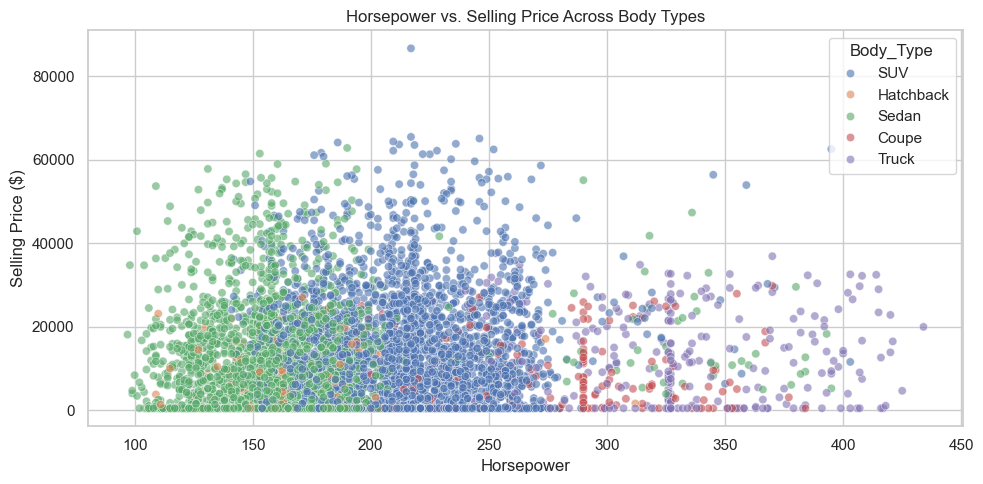

In [66]:
# Visualizing Horsepower vs Selling Price by Body Type
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x="Horsepower",
    y="Selling_Price",
    hue="Body_Type",
    alpha=0.6,
)
plt.title("Horsepower vs. Selling Price Across Body Types")
plt.xlabel("Horsepower")
plt.ylabel("Selling Price ($)")
# Save the figure (dpi=300 ensures high resolution for reports/presentations)
plt.savefig("Horsepower vs. Selling Price Across Body Types.png", 
            dpi=300, bbox_inches="tight")
plt.show()

## Depreciation & Mileage Interaction

In [67]:
# Create interaction term
df["Age_Mileage_Interaction"] = df["Vehicle_Age"] * df["Mileage"]

In [68]:
# Correlation analysis on Price Retention
depreciation_corr = df[
    ["Vehicle_Age", "Mileage", "Age_Mileage_Interaction", "Selling_Price"]
].corr()["Selling_Price"]
print("Correlation matrix with Selling Price:")
print(depreciation_corr)

Correlation matrix with Selling Price:
Vehicle_Age               -0.804933
Mileage                   -0.682883
Age_Mileage_Interaction   -0.654684
Selling_Price              1.000000
Name: Selling_Price, dtype: float64


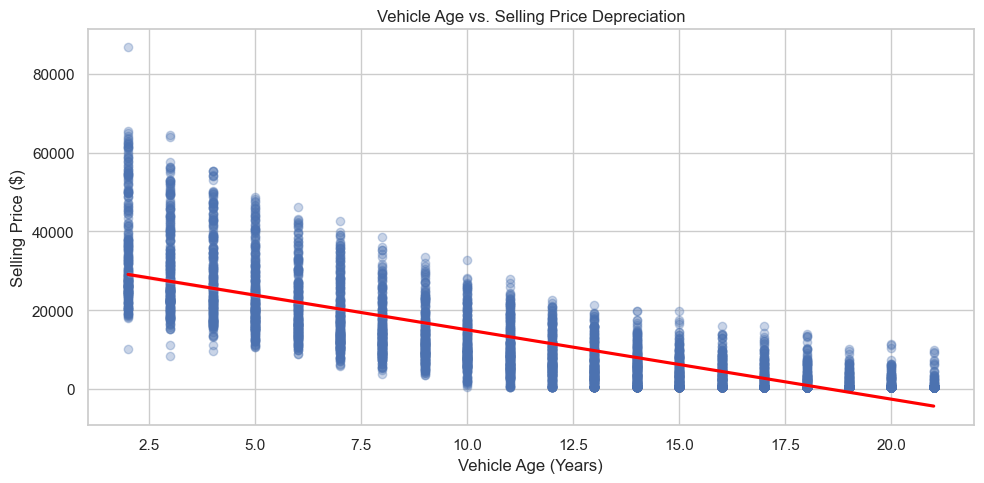

In [69]:
# Visualizing Age vs Price
plt.figure(figsize=(10, 5))
sns.regplot(
    data=df,
    x="Vehicle_Age",
    y="Selling_Price",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"},
)
plt.title("Vehicle Age vs. Selling Price Depreciation")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Selling Price ($)")
# Save the figure (dpi=300 ensures high resolution for reports/presentations)
plt.savefig("Vehicle Age vs. Selling Price Depreciation.png", 
            dpi=300, bbox_inches="tight")
plt.show()

## Accident & Service History Price Penalty

In [70]:
# Compare mean selling prices by accident history
accident_penalty = df.groupby("Accident_History")["Selling_Price"].agg(
    ["mean", "median", "count"]
)
print("Impact of Accident History on Price:")
print(accident_penalty)

Impact of Accident History on Price:
                          mean   median  count
Accident_History                              
0                 15530.067187  12916.0   3587
1                  6300.550967   3481.0   1913


In [71]:
# Extract original Service_History column before dummies if needed, or inspect encoded columns
service_cols = [c for c in df.columns if c.startswith("Service_History_")]
if service_cols:
  print("\nMean Selling Price by Service History Type:")
  for col in service_cols:
    print(f"{col}: ${df[df[col] == 1]['Selling_Price'].mean():,.2f}")

## Regional Concentration & Market Preferences

### Categorical Encoding

In [72]:
# One-Hot Encoding for low-cardinality nominal features
one_hot_cols = [
    "Fuel_Type",
    "Transmission",
    "Body_Type",
    "Drivetrain",
    "Service_History",
]
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)

In [73]:
# Frequency Encoding for high-cardinality features (Make, Model, Location, Color)
for col in ["Make", "Model", "Location", "Color"]:
  freq = df[col].value_counts() / len(df)
  df[f"{col}_Freq"] = df[col].map(freq)

In [74]:
# Verify the Cleaned Dataframe
print("Missing values after cleaning:")
print(df.isnull().sum().sum())
df.head()

Missing values after cleaning:
0


,Make,Model,Year,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Color,...,Drivetrain_AWD,Drivetrain_FWD,Drivetrain_RWD,Service_History_No Service,Service_History_Partial Service,Service_History_Unknown,Make_Freq,Model_Freq,Location_Freq,Color_Freq
0,Mercedes-Benz,GLE,2024,2.3,100,186.0,196.0,1,0,Silver,...,True,False,False,False,False,True,0.098364,0.030182,0.082182,0.100000
1,Hyundai,Tucson,2008,2.3,387035,189.0,190.0,4,0,Blue,...,False,True,False,False,False,True,0.105273,0.023818,0.078727,0.107091
2,Volkswagen,Golf,2021,1.9,46054,158.0,153.0,1,0,Gray,...,True,False,False,False,True,False,0.103455,0.023455,0.088364,0.106727
3,Chevrolet,Tahoe,2005,2.2,141302,169.0,165.0,5,1,Blue,...,True,False,False,True,False,False,0.101091,0.021818,0.078727,0.107091
4,Toyota,Camry,2022,1.9,32813,149.0,141.0,1,0,Brown,...,False,True,False,False,False,False,0.096545,0.024545,0.090000,0.259455


## Crosstab of Location Frequencies vs Body Type / Drivetrain preferences

In [75]:
# Top locations by frequency
top_locations = df["Location_Freq"].value_counts().head(5).index

regional_body = pd.crosstab(
    df["Location_Freq"],
    df["Body_Type_Sedan"] if "Body_Type_Sedan" in df.columns else df.index,
    normalize="index",
)
print("Regional Distribution Sample:")
print(regional_body.head())

Regional Distribution Sample:
Body_Type_Sedan     False     True 
Location_Freq                      
0.078727         0.586605  0.413395
0.079455         0.601831  0.398169
0.080909         0.602247  0.397753
0.082182         0.599558  0.400442
0.086182         0.592827  0.407173
